# Task 3: Real-Time Echocardiogram Video Analysis
**Medical Imaging Portfolio** | Author: **23k0069**

### Scenario
Ultrasound echocardiogram footage is notoriously murky, low-contrast, and degraded by probe acoustic backscatter.
This real-time pipeline captures video frame-by-frame, equalizing contrast, mapping pseudocolor jet flow, balancing chrominance, expanding dark chambers via logarithmic curves, and attenuating backscatter using power-law tuning.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
print('Video analysis pipeline ready.')

Video analysis pipeline ready.


## 1. Video Capture Setup
Initialize `cv2.VideoCapture` from `data/echocardiogram.mp4` and inspect stream dimensions.

In [2]:
cap = cv2.VideoCapture('data/echocardiogram.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f'Echo Stream: {w}x{h} Resolution | {fps} FPS | Total Frame Count: {count}')

Echo Stream: 480x360 Resolution | 25.0 FPS | Total Frame Count: 50


## 2. Frame Mathematical Enhancement Function
Matrix processing per frame:
1. Single-channel luminance conversion
2. Histogram Equalization (combats murky acoustic attenuation)
3. False-Color Mapping (`COLORMAP_JET` highlighting blood flow velocities)
4. Gray-World Color Balance
5. Logarithmic Transformation (reveals dark ventricular recesses)
6. Power-Law Suppression ($\gamma = 1.35$ suppresses blinding white probe backscatter)

In [3]:
def enhance_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if len(frame.shape) == 3 else frame
    
    # 1. Histogram Equalization
    eq = cv2.equalizeHist(gray)
    
    # 2. Color Mapping (Jet)
    heat = cv2.applyColorMap(eq, cv2.COLORMAP_JET)
    
    # 3. Color Balance (Gray-World)
    b, g, r = cv2.split(heat)
    mb, mg, mr = b.mean(), g.mean(), r.mean()
    avg = (mb + mg + mr) / 3.0
    b_cb = np.clip(b * (avg / mb), 0, 255).astype(np.uint8)
    g_cb = np.clip(g * (avg / mg), 0, 255).astype(np.uint8)
    r_cb = np.clip(r * (avg / mr), 0, 255).astype(np.uint8)
    cb = cv2.merge([b_cb, g_cb, r_cb])
    
    # 4. Logarithmic Transformation
    c_log = 255.0 / np.log(1.0 + np.max(cb))
    log_f = (c_log * np.log(1.0 + cb.astype(np.float32))).astype(np.uint8)
    
    # 5. Power-Law (Gamma = 1.35 suppresses white backscatter)
    gamma = 1.35
    enh = np.clip(255.0 * ((log_f / 255.0) ** gamma), 0, 255).astype(np.uint8)
    return enh

print('Enhancement function compiled.')

Enhancement function compiled.


## 3. Real-Time Video Processing Loop
Iterate through the video stream, process each frame, and save the side-by-side concatenated monitoring array to `output/side_by_side_echo.mp4`.

In [4]:
cap = cv2.VideoCapture('data/echocardiogram.mp4')
out = cv2.VideoWriter('output/side_by_side_echo.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w * 2, h))

sample_frames = []
idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    enh = enhance_frame(frame)
    side_by_side = np.hstack([frame, enh])
    out.write(side_by_side)
    
    if idx in [10, 25, 40]:
        sample_frames.append((idx, frame, enh))
    idx += 1

cap.release()
out.release()
print(f'Processed {idx} frames. Video saved to output/side_by_side_echo.mp4')

Processed 50 frames. Video saved to output/side_by_side_echo.mp4


## 4. Visual Inspection of Monitored Ultrasound Frames
Side-by-side comparison across key stages of ventricular systole and diastole.

Saved representative frame to output/side_by_side_frame.png


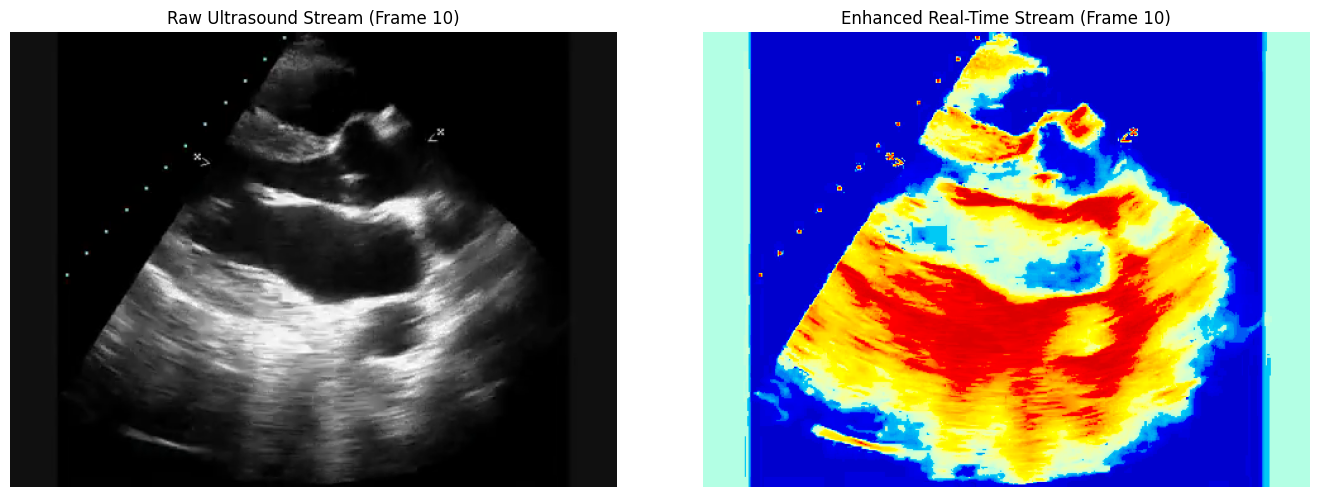

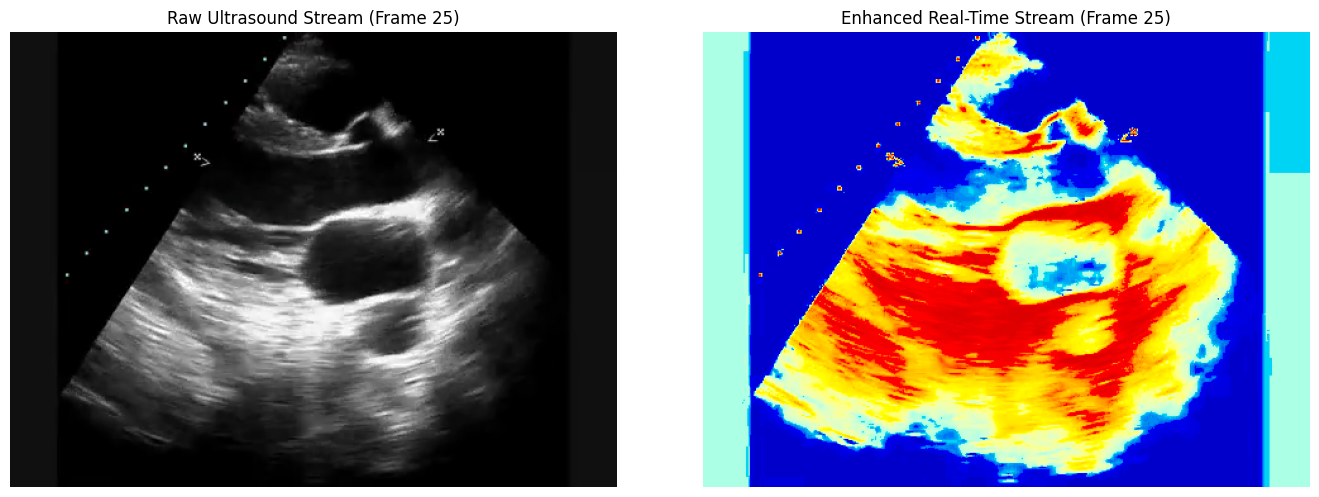

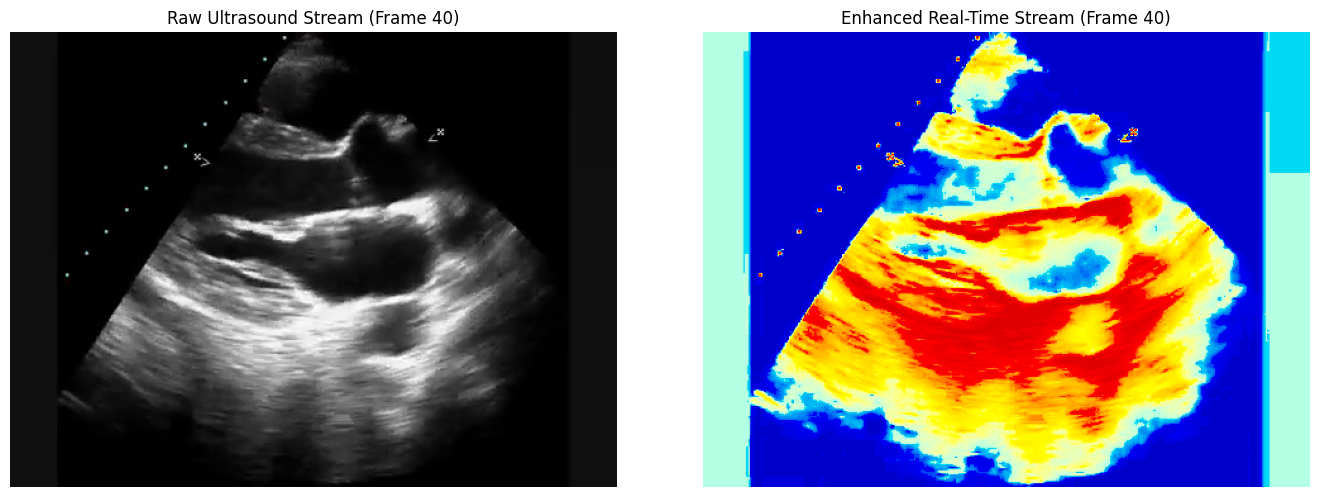

In [5]:
for frame_idx, raw_f, enh_f in sample_frames:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(cv2.cvtColor(raw_f, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Raw Ultrasound Stream (Frame {frame_idx})')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(enh_f, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Enhanced Real-Time Stream (Frame {frame_idx})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(f'output/echo_frame_{frame_idx}_comparison.png', bbox_inches='tight')
    plt.show()

rep_frame = np.hstack([sample_frames[1][1], sample_frames[1][2]])
cv2.imwrite('output/side_by_side_frame.png', rep_frame)
print('Saved representative frame to output/side_by_side_frame.png')